<a href="https://colab.research.google.com/github/Sayaniadak/cnn-model/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Alternative method
import os
from google.colab import auth
from google.colab import drive

# Authenticate first
auth.authenticate_user()

# Then mount
drive.mount('/content/drive', force_remount=True)

print("Connected!")

# Verify connection
if os.path.exists('/content/drive/MyDrive'):
    print("Drive mounted successfully!")
    print("Folders in your Drive:")
    folders = os.listdir('/content/drive/MyDrive')
    for f in folders:
        print(f"  {f}")
else:
    print("Mount failed - try again")

Mounted at /content/drive
Connected!
Drive mounted successfully!
Folders in your Drive:
  Sayani Adak.jpg
  Hostel Acknowledgement Receipt Sayani Adak.doc
  DOC-20231004-WA0001..pdf
  Project (1).gsite
  Sayani.gsite
  Project.gsite
  Portfolio.gsite
  Picture
  IMG_20230922_185617_932_11zon (1).webp
  Sreya
  Doc Scanner
  Doc Scanner Upload
  Assignment 1
  Assignment 1-1(994044995665256).jpg
  English assignment 
  Assignment 1.pdf
  English Assignment 1.pdf
  Screenshot_2024-04-23-10-42-04-65_944a2809ea1b4cda6ef12d1db9048ed3.jpg
  DocScanner 17 May 2024 19-44.pdf
  ADMIT CARD SEM 2.pdf
  JIBAN DROPS.pdf
  GROCERY POSTERS (1).pdf
  JEWELLARY POSTRES DESIGNS.pdf
  FULL STACK POSTER.pdf
  vector image pdf.pdf
  Take a look at my Canva design!
  perfume label.png
  PERFUME LABEL.pdf
  GTL Tasks (Sayani Adak).pdf
  mockup.pdf
  IMG_20240318_130400 (1) (1).jpg
  Sayani Adak .pdf
  GROCERY POSTERS.pdf
  face 3 intro
  IMG_20240318_130400 (1).jpg
  new_1_intro RPaper.pdf
  DocScanner 18 Se

In [ ]:
# CELL 2: Install and import all required libraries

# Install libraries
!pip install opencv-python-headless -q
!pip install seaborn -q

# Import everything
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

# Check GPU
print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.test.is_gpu_available()}")

# Check GPU details
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU Device: {gpu_devices}")
else:
    print("No GPU found — using CPU (slower but works)")

Libraries imported successfully!
TensorFlow version: 2.19.0
GPU Available: True
GPU Device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# CELL 3: Set all paths
# IMPORTANT: Change DATASET_PATH to match where
# your folder is in Google Drive

# Your dataset location in Google Drive
DATASET_PATH = "/content/drive/MyDrive/face_dataset"

# Where to save results (will be created automatically)
RESULTS_PATH = "/content/drive/MyDrive/face_results"
MODELS_PATH  = "/content/drive/MyDrive/face_models"

# Create output folders
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH,  exist_ok=True)

# Settings
IMAGE_SIZE   = 128    # all images resized to 128x128
NUM_PHOTOS   = 20     # photos per person per condition

print("Paths configured!")
print(f"Dataset  : {DATASET_PATH}")
print(f"Results  : {RESULTS_PATH}")
print(f"Models   : {MODELS_PATH}")

# Verify dataset folder exists
if os.path.exists(DATASET_PATH):
    print(f"\nDataset folder found!")
    persons = [p for p in os.listdir(DATASET_PATH)
               if os.path.isdir(os.path.join(DATASET_PATH, p))]
    print(f"Persons found: {persons}")
else:
    print(f"\nERROR: Dataset folder not found!")
    print(f"Check your Google Drive path")

Paths configured!
Dataset  : /content/drive/MyDrive/face_dataset
Results  : /content/drive/MyDrive/face_results
Models   : /content/drive/MyDrive/face_models

Dataset folder found!
Persons found: ['sayani', 'Rohit', 'sumouli', 'spandan']


In [ ]:
# CELL 4: Check your dataset is complete

def verify_dataset(dataset_path):

    print("\n" + "="*55)
    print("  DATASET VERIFICATION")
    print("="*55)

    conditions = ["normal_light", "dim_light",
                  "low_light", "motion"]

    if not os.path.exists(dataset_path):
        print("ERROR: Dataset folder not found!")
        return False

    persons = sorted([
        p for p in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, p))
    ])

    if len(persons) == 0:
        print("ERROR: No persons found!")
        return False

    print(f"Persons found: {len(persons)}")

    total = 0
    all_complete = True

    for person in persons:
        print(f"\n  Person: {person}")
        person_total = 0

        for condition in conditions:
            path = os.path.join(dataset_path, person, condition)

            if os.path.exists(path):
                images = [
                    f for f in os.listdir(path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                ]
                count = len(images)
                person_total += count

                if count >= 20:
                    status = "✅ OK"
                elif count > 0:
                    status = f"⚠️ Only {count}/20"
                    all_complete = False
                else:
                    status = "❌ EMPTY"
                    all_complete = False

                print(f"    {condition:15s}: {count:3d} photos {status}")
            else:
                print(f"    {condition:15s}: ❌ FOLDER MISSING")
                all_complete = False

        print(f"    {'TOTAL':15s}: {person_total} photos")
        total += person_total

    print(f"\n{'='*55}")
    print(f"  TOTAL IMAGES: {total}")

    if all_complete:
        print("  STATUS: ✅ DATASET IS COMPLETE!")
    else:
        print("  STATUS: ⚠️ SOME DATA MISSING")
        print("  Please upload missing photos to Drive")

    print("="*55)
    return persons

# Run verification
persons = verify_dataset(DATASET_PATH)


  DATASET VERIFICATION
Persons found: 4

  Person: Rohit
    normal_light   :  20 photos ✅ OK
    dim_light      :  20 photos ✅ OK
    low_light      :  20 photos ✅ OK
    motion         :  20 photos ✅ OK
    TOTAL          : 80 photos

  Person: sayani
    normal_light   :  20 photos ✅ OK
    dim_light      :  20 photos ✅ OK
    low_light      :  20 photos ✅ OK
    motion         :  20 photos ✅ OK
    TOTAL          : 80 photos

  Person: spandan
    normal_light   :  20 photos ✅ OK
    dim_light      :  18 photos ⚠️ Only 18/20
    low_light      :  25 photos ✅ OK
    motion         :  22 photos ✅ OK
    TOTAL          : 85 photos

  Person: sumouli
    normal_light   :  30 photos ✅ OK
    dim_light      :  20 photos ✅ OK
    low_light      :  25 photos ✅ OK
    motion         :  21 photos ✅ OK
    TOTAL          : 96 photos

  TOTAL IMAGES: 341
  STATUS: ⚠️ SOME DATA MISSING
  Please upload missing photos to Drive


In [ ]:
# Refresh Google Drive connection
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
print("Drive reconnected!")

Mounted at /content/drive
Drive reconnected!


In [ ]:
# This will show EXACT folder names in your Drive
import os

base = "/content/drive/MyDrive/face_dataset"

for person in os.listdir(base):
    person_path = os.path.join(base, person)
    if os.path.isdir(person_path):
        print(f"\nPerson: '{person}'")
        for folder in os.listdir(person_path):
            folder_path = os.path.join(person_path, folder)
            if os.path.isdir(folder_path):
                files = os.listdir(folder_path)
                print(f"  Folder: '{folder}' → {len(files)} files")


Person: 'sayani'
  Folder: 'motion' → 20 files
  Folder: 'normal_light' → 20 files
  Folder: 'dim_light' → 20 files
  Folder: 'low_light' → 20 files

Person: 'Rohit'
  Folder: 'dim_light' → 20 files
  Folder: 'low_light' → 20 files
  Folder: 'motion' → 20 files
  Folder: 'normal_light' → 20 files

Person: 'sumouli'
  Folder: 'dim_light' → 20 files
  Folder: 'low_light' → 25 files
  Folder: 'motion' → 21 files
  Folder: 'normal_light' → 30 files

Person: 'spandan'
  Folder: 'low_light' → 25 files
  Folder: 'dim_light' → 18 files
  Folder: 'normal_light' → 20 files
  Folder: 'motion' → 22 files


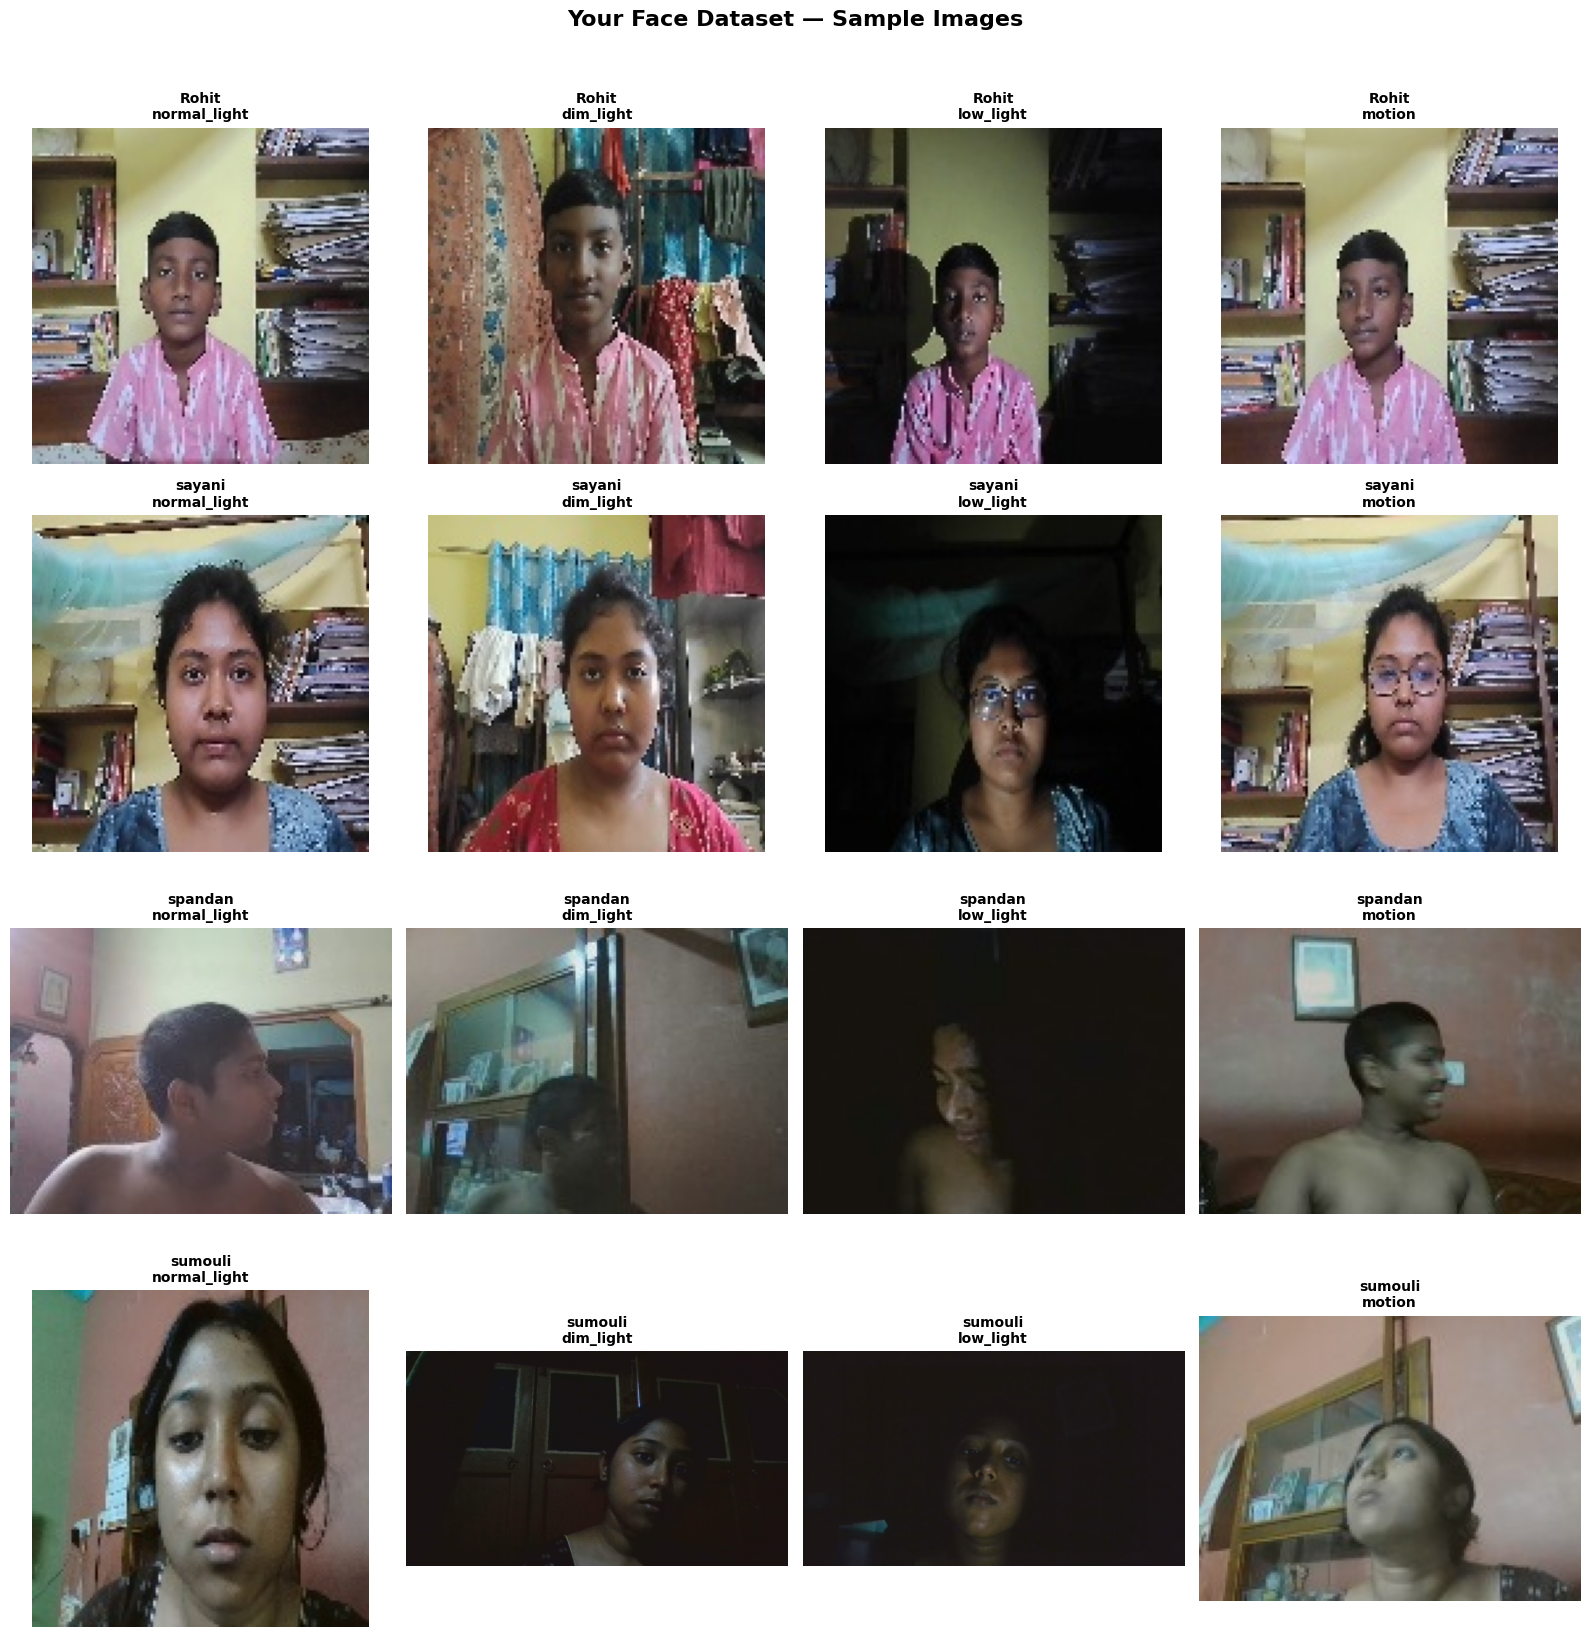


Saved to: /content/drive/MyDrive/face_results/dataset_samples.png


In [ ]:
# CELL 5: Visualize sample photos from your dataset

def show_dataset_samples(dataset_path, persons):

    conditions = ["normal_light", "dim_light",
                  "low_light", "motion"]

    num_persons = len(persons)

    fig, axes = plt.subplots(
        num_persons, 4,
        figsize=(16, 4 * num_persons)
    )

    # Handle case with only 1 person
    if num_persons == 1:
        axes = [axes]

    for i, person in enumerate(persons):
        for j, condition in enumerate(conditions):

            ax = axes[i][j]
            path = os.path.join(dataset_path, person, condition)

            if os.path.exists(path):
                images = sorted([
                    f for f in os.listdir(path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                ])

                if images:
                    img_path = os.path.join(path, images[0])
                    img = cv2.imread(img_path)

                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        ax.imshow(img)
                        ax.set_title(
                            f"{person}\n{condition}",
                            fontsize=10, fontweight='bold'
                        )
                        ax.axis('off')
                    else:
                        ax.text(0.5, 0.5, 'Cannot\nload',
                               ha='center', va='center',
                               color='red')
                        ax.axis('off')
                else:
                    ax.text(0.5, 0.5, 'No\nImages',
                           ha='center', va='center', color='red')
                    ax.axis('off')
            else:
                ax.text(0.5, 0.5, 'Folder\nMissing',
                       ha='center', va='center', color='red')
                ax.axis('off')

    plt.suptitle(
        'Your Face Dataset — Sample Images',
        fontsize=16, fontweight='bold', y=1.02
    )
    plt.tight_layout()

    save_path = os.path.join(RESULTS_PATH, 'dataset_samples.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved to: {save_path}")

# Show samples
show_dataset_samples(DATASET_PATH, persons)

In [ ]:
# CELL 6: Function to load dataset

def load_dataset(dataset_path, num_images_per_person=20):
    """
    Loads your custom dataset

    num_images_per_person:
    10 = first experiment
    15 = second experiment
    20 = third experiment
    """

    X = []      # images
    y = []      # labels

    conditions = ["normal_light", "dim_light",
                  "low_light", "motion"]

    person_list = sorted([
        p for p in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, p))
    ])

    print(f"\nLoading {num_images_per_person} images per person...")
    print("="*50)

    for label_num, person in enumerate(person_list):

        images_loaded = 0

        for condition in conditions:

            if images_loaded >= num_images_per_person:
                break

            folder = os.path.join(dataset_path, person, condition)

            if not os.path.exists(folder):
                continue

            image_files = sorted([
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg','.jpeg','.png'))
            ])

            for img_file in image_files:

                if images_loaded >= num_images_per_person:
                    break

                img_path = os.path.join(folder, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is None:
                    continue

                # Resize
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

                # Normalize to 0-1
                img = img.astype(np.float32) / 255.0

                X.append(img)
                y.append(label_num)
                images_loaded += 1

        print(f"  {person:15s}: {images_loaded} images loaded")

    # Convert to arrays
    X = np.array(X)
    y = np.array(y)

    # Add channel dimension
    X = X.reshape(X.shape[0], IMAGE_SIZE, IMAGE_SIZE, 1)

    print(f"\nTotal loaded: {len(X)} images")
    print(f"Shape: {X.shape}")
    print(f"Classes: {len(person_list)} people")

    return X, y, person_list


def split_data(X, y, num_classes):
    """Splits into train/validation/test"""

    y_cat = to_categorical(y, num_classes)

    # 70% train
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_cat,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # 15% val, 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        random_state=42
    )

    print(f"\nData Split:")
    print(f"  Train      : {len(X_train)} images")
    print(f"  Validation : {len(X_val)} images")
    print(f"  Test       : {len(X_test)} images")

    return X_train, X_val, X_test, y_train, y_val, y_test

print("Dataset loading functions ready!")

Dataset loading functions ready!


In [ ]:
# CELL 7: Balanced CNN using GlobalAveragePooling

def build_cnn_model(input_shape, num_classes):

    model = Sequential([

        # BLOCK 1
        # Learns basic features like edges and lines
        Conv2D(32, (3,3), activation='relu',
               padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # BLOCK 2
        # Learns facial parts like eyes nose mouth
        Conv2D(64, (3,3), activation='relu',
               padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # BLOCK 3
        # Learns complete face patterns
        Conv2D(128, (3,3), activation='relu',
               padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # GLOBAL AVERAGE POOLING
        # This replaces Flatten
        # Converts 16x16x128 → only 128 values
        # Reduces parameters massively
        tf.keras.layers.GlobalAveragePooling2D(),

        # DENSE LAYER
        # Makes final decision
        Dense(128, activation='relu'),
        Dropout(0.4),

        # OUTPUT LAYER
        # One output per person
        Dense(num_classes, activation='softmax',
              name='output')

    ], name='Face_CNN_Balanced')

    return model


# Test the model
test_model = build_cnn_model((128, 128, 1), 4)
test_model.summary()
print(f"\nTotal parameters: {test_model.count_params():,}")

Model: "Face_CNN_Balanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 110,596


In [ ]:
# CELL 8: Complete training function

def train_experiment(num_images_per_person, experiment_name):
    """
    Runs one complete training experiment
    """

    print("\n" + "🔥"*20)
    print(f"  STARTING: {experiment_name}")
    print(f"  Images per person: {num_images_per_person}")
    print("🔥"*20)

    # ---- LOAD DATA ----
    X, y, person_list = load_dataset(
        DATASET_PATH,
        num_images_per_person
    )
    num_classes = len(person_list)

    # ---- SPLIT DATA ----
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, num_classes
    )

    # ---- BUILD MODEL ----
    print("\nBuilding model...")
    model = build_cnn_model((IMAGE_SIZE, IMAGE_SIZE, 1), num_classes)

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # ---- CALLBACKS ----
    model_save_path = os.path.join(
        MODELS_PATH, f'cnn_{experiment_name}.h5'
    )

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=30,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=15,
            min_lr=0.000001,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

    # ---- TRAIN WITH AUGMENTATION ----
    print("\nTraining started...")
    print("Watch accuracy increase each epoch\n")

    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.8, 1.2]
    )

    datagen.fit(X_train)

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=8),
        validation_data=(X_val, y_val),
        epochs=150,
        callbacks=callbacks,
        verbose=1
    )

    # ---- EVALUATE ----
    print("\nEvaluating on test set...")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    accuracy  = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(
        y_true, y_pred, average='weighted', zero_division=0) * 100
    recall    = recall_score(
        y_true, y_pred, average='weighted', zero_division=0) * 100
    f1        = f1_score(
        y_true, y_pred, average='weighted', zero_division=0) * 100

    print(f"\n{'='*45}")
    print(f"  ✅ RESULTS: {experiment_name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy:.2f}%")
    print(f"  Precision : {precision:.2f}%")
    print(f"  Recall    : {recall:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"{'='*45}")

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=person_list,
        zero_division=0
    ))

    # ---- SAVE RESULTS ----
    results = {
        'experiment': experiment_name,
        'num_images_per_person': num_images_per_person,
        'num_people': num_classes,
        'accuracy': round(accuracy, 2),
        'precision': round(precision, 2),
        'recall': round(recall, 2),
        'f1_score': round(f1, 2),
        'epochs_trained': len(history.history['accuracy'])
    }

    results_file = os.path.join(
        RESULTS_PATH, f'{experiment_name}_results.json'
    )
    with open(results_file, 'w') as f:
        json.dump(results, f, indent=4)

    # ---- PLOTS ----
    plot_training_curves(history, experiment_name)
    plot_confusion_matrix(y_true, y_pred, person_list, experiment_name)

    return results, model, history, person_list

print("Training function ready!")

Training function ready!


In [ ]:
# CELL 9: All plotting functions

def plot_training_curves(history, experiment_name):
    """Training accuracy and loss curves"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(epochs, history.history['accuracy'],
                'b-', linewidth=2, label='Training')
    axes[0].plot(epochs, history.history['val_accuracy'],
                'r-', linewidth=2, label='Validation')
    axes[0].set_title(f'Model Accuracy\n{experiment_name}',
                     fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1.1)

    # Loss
    axes[1].plot(epochs, history.history['loss'],
                'b-', linewidth=2, label='Training')
    axes[1].plot(epochs, history.history['val_loss'],
                'r-', linewidth=2, label='Validation')
    axes[1].set_title(f'Model Loss\n{experiment_name}',
                     fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(
        RESULTS_PATH, f'training_curves_{experiment_name}.png'
    )
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


def plot_confusion_matrix(y_true, y_pred, person_list, experiment_name):
    """Confusion matrix heatmap"""

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(max(8, len(person_list)*2),
                        max(6, len(person_list)*1.5)))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=person_list,
        yticklabels=person_list,
        linewidths=1
    )

    plt.title(f'Confusion Matrix — {experiment_name}',
             fontsize=13, fontweight='bold')
    plt.ylabel('Actual Person', fontsize=11)
    plt.xlabel('Predicted Person', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    save_path = os.path.join(
        RESULTS_PATH, f'confusion_matrix_{experiment_name}.png'
    )
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


def plot_final_comparison(all_results):
    """Final comparison bar chart — this goes in your paper"""

    experiments = [f"{r['num_images_per_person']} Images\nper Person"
                   for r in all_results]

    accuracy  = [r['accuracy']  for r in all_results]
    precision = [r['precision'] for r in all_results]
    recall    = [r['recall']    for r in all_results]
    f1_scores = [r['f1_score']  for r in all_results]

    x = np.arange(len(experiments))
    width = 0.2

    fig, ax = plt.subplots(figsize=(14, 7))

    b1 = ax.bar(x - 1.5*width, accuracy,  width,
               label='Accuracy',  color='#2196F3', edgecolor='black')
    b2 = ax.bar(x - 0.5*width, precision, width,
               label='Precision', color='#4CAF50', edgecolor='black')
    b3 = ax.bar(x + 0.5*width, recall,    width,
               label='Recall',    color='#FF9800', edgecolor='black')
    b4 = ax.bar(x + 1.5*width, f1_scores, width,
               label='F1 Score',  color='#E91E63', edgecolor='black')

    # Value labels on bars
    for bars in [b1, b2, b3, b4]:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                h + 0.3,
                f'{h:.1f}%',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )

    ax.set_xlabel('Training Dataset Size', fontsize=12)
    ax.set_ylabel('Performance (%)', fontsize=12)
    ax.set_title(
        'CNN Performance vs Dataset Size\n'
        '(Custom Face Dataset — Low Light Conditions)',
        fontsize=14, fontweight='bold'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(experiments, fontsize=11)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 115)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_PATH, 'final_comparison_CNN.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {save_path}")
    print("This graph goes directly into your paper!")


def plot_lighting_performance(model, X_test_normal, y_test,
                               experiment_name):
    """Tests model across different lighting levels"""

    def simulate_dark(images, alpha):
        return images * alpha

    conditions = {
        'Normal Light': X_test_normal,
        'Dim Light': simulate_dark(X_test_normal, 0.6),
        'Low Light': simulate_dark(X_test_normal, 0.3),
        'Very Dark': simulate_dark(X_test_normal, 0.1)
    }

    y_true = np.argmax(y_test, axis=1)
    results = []

    print("\nTesting across lighting conditions...")
    for condition_name, X_condition in conditions.items():
        y_pred = np.argmax(
            model.predict(X_condition, verbose=0), axis=1
        )
        acc = accuracy_score(y_true, y_pred) * 100
        results.append({'condition': condition_name, 'accuracy': acc})
        print(f"  {condition_name:15s}: {acc:.2f}%")

    # Plot
    cond_names = [r['condition'] for r in results]
    accuracies = [r['accuracy'] for r in results]
    colors = ['#4CAF50', '#2196F3', '#FF9800', '#f44336']

    plt.figure(figsize=(10, 6))
    bars = plt.bar(cond_names, accuracies,
                   color=colors, edgecolor='black', width=0.5)

    for bar, acc in zip(bars, accuracies):
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{acc:.1f}%',
            ha='center', fontsize=13, fontweight='bold'
        )

    plt.title(
        f'CNN Accuracy Under Different Lighting\n{experiment_name}',
        fontsize=14, fontweight='bold'
    )
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(0, 115)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(
        RESULTS_PATH, f'lighting_performance_{experiment_name}.png'
    )
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    return results

print("Plotting functions ready!")

Plotting functions ready!


EXPERIMENT 1 STARTING
Training CNN with 10 images per person

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
  STARTING: Exp1_10images
  Images per person: 10
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

Loading 10 images per person...
  Rohit          : 10 images loaded
  sayani         : 10 images loaded
  spandan        : 10 images loaded
  sumouli        : 10 images loaded

Total loaded: 40 images
Shape: (40, 128, 128, 1)
Classes: 4 people

Data Split:
  Train      : 28 images
  Validation : 6 images
  Test       : 6 images

Building model...

Training started...
Watch accuracy increase each epoch

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2411 - loss: 1.3863 

4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.2143 - loss: 1.3864 - val_accuracy: 0.1667 - val_loss: 1.4000 - learning_rate: 5.0000e-04
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.1667 - val_loss: 1.4010 - learning_rate: 5.0000e-04
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.1667 - val_loss: 1.4019 - learning_rate: 5.0000e-04
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.1667 - val_loss: 1.4030 - learning_rate: 5.0000e-04
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1786 - loss: 1.3863 - val_accuracy: 0.1667 - val_loss: 1.4042 - learning_rate: 5.0000e-04
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.1667 - val_loss: 1.4055 - learning_rate: 5.0000e-04
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2500 - loss: 1.3863 - val

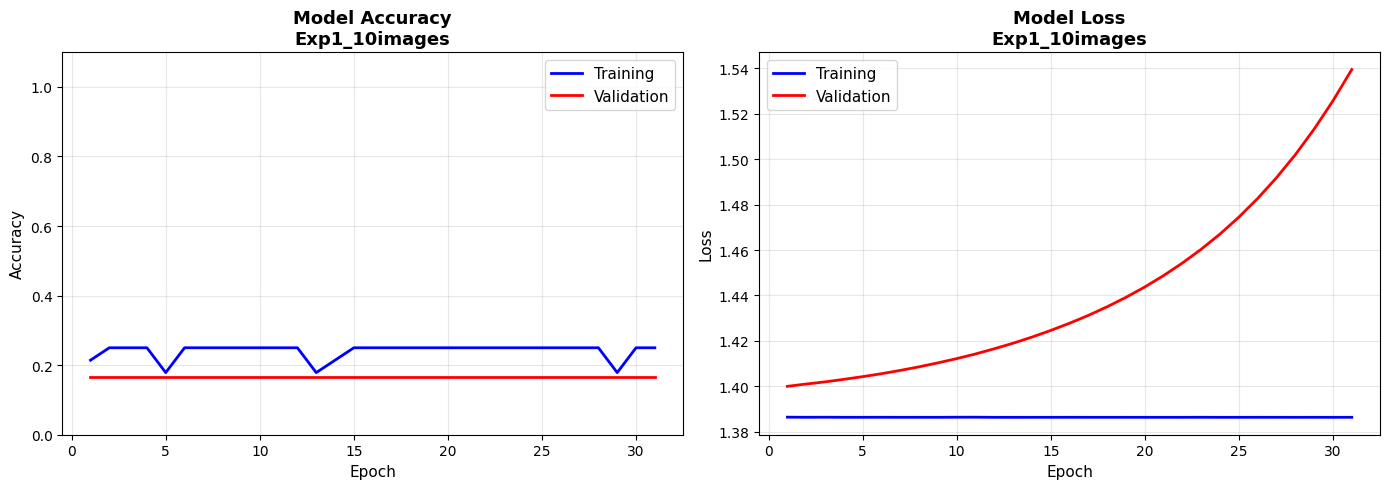

Saved: /content/drive/MyDrive/face_results/training_curves_Exp1_10images.png


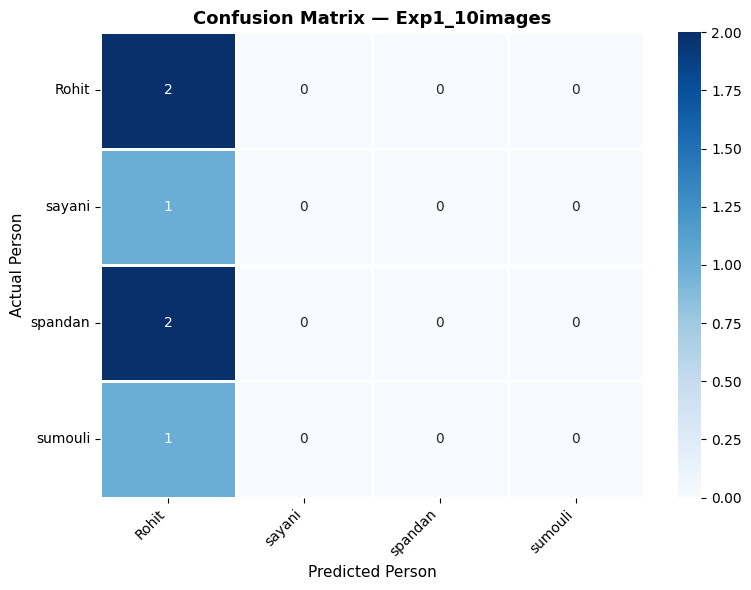

Saved: /content/drive/MyDrive/face_results/confusion_matrix_Exp1_10images.png

Experiment 1 Complete!
Accuracy: 33.33%


In [ ]:
# CELL 10: EXPERIMENT 1 — 10 images per person

print("EXPERIMENT 1 STARTING")
print("Training CNN with 10 images per person")
print("="*50)

results_10, model_10, history_10, people = train_experiment(
    num_images_per_person = 10,
    experiment_name = "Exp1_10images"
)

print("\nExperiment 1 Complete!")
print(f"Accuracy: {results_10['accuracy']}%")

EXPERIMENT 2 STARTING
Training CNN with 15 images per person

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
  STARTING: Exp2_15images
  Images per person: 15
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

Loading 15 images per person...
  Rohit          : 15 images loaded
  sayani         : 15 images loaded
  spandan        : 15 images loaded
  sumouli        : 15 images loaded

Total loaded: 60 images
Shape: (60, 128, 128, 1)
Classes: 4 people

Data Split:
  Train      : 42 images
  Validation : 9 images
  Test       : 9 images

Building model...

Training started...
Watch accuracy increase each epoch

Epoch 1/150
5/6 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.1565 - loss: 1.3863  

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.1429 - loss: 1.3864 - val_accuracy: 0.1111 - val_loss: 1.3891 - learning_rate: 5.0000e-04
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2619 - loss: 1.3863 - val_accuracy: 0.1111 - val_loss: 1.3894 - learning_rate: 5.0000e-04
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2619 - loss: 1.3863 - val_accuracy: 0.1111 - val_loss: 1.3896 - learning_rate: 5.0000e-04
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2619 - loss: 1.3863 - val_accuracy: 0.1111 - val_loss: 1.3899 - learning_rate: 5.0000e-04
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2619 - loss: 1.3863 - val_accuracy: 0.1111 - val_loss: 1.3902 - learning_rate: 5.0000e-04
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2619 - loss: 1.3863 - val_accuracy: 0.1111 - val_loss: 1.3907 - learning_rate: 5.0000e-04
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2619 - loss: 1.3863 - val

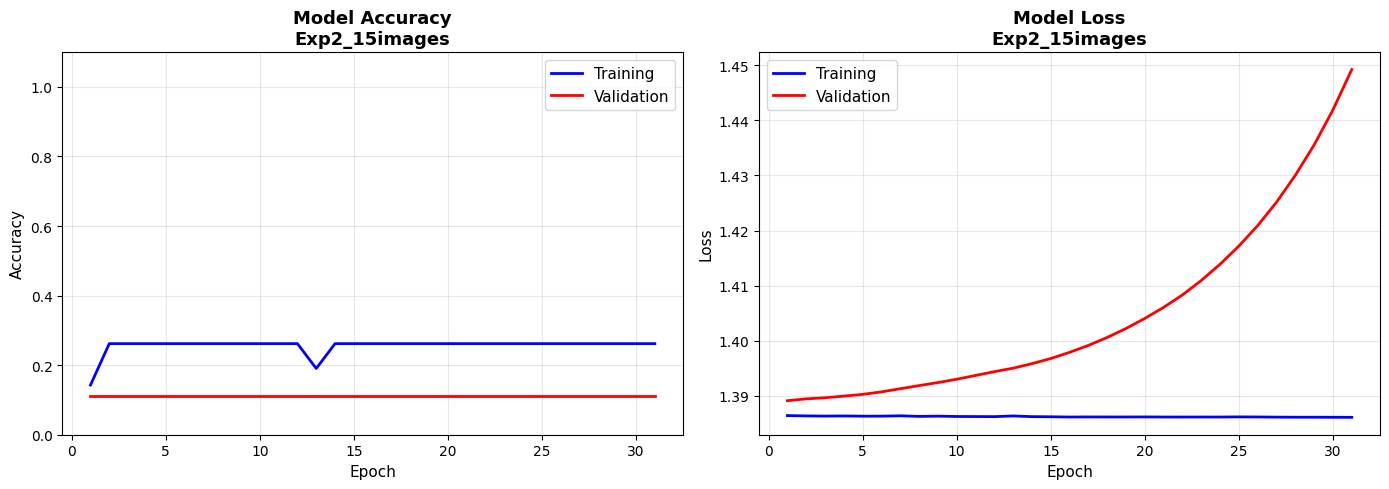

Saved: /content/drive/MyDrive/face_results/training_curves_Exp2_15images.png


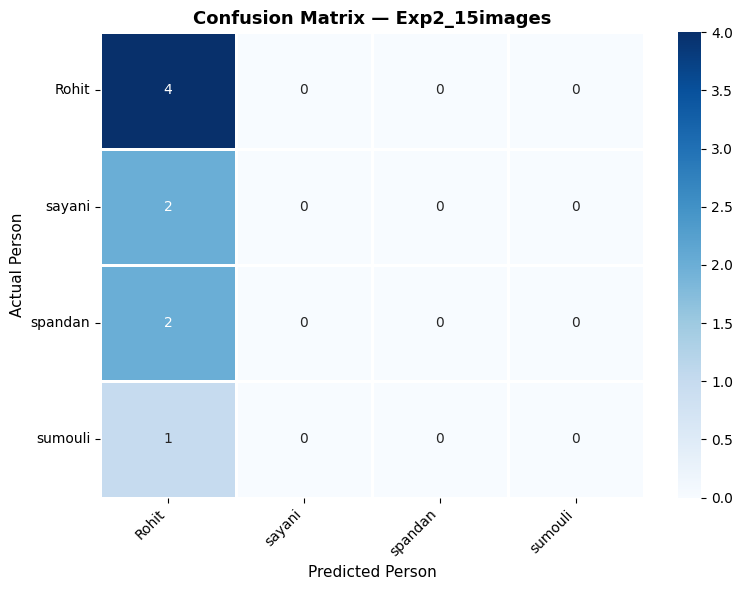

Saved: /content/drive/MyDrive/face_results/confusion_matrix_Exp2_15images.png

Experiment 2 Complete!
Accuracy: 44.44%


In [ ]:
# CELL 11: EXPERIMENT 2 — 15 images per person

print("EXPERIMENT 2 STARTING")
print("Training CNN with 15 images per person")
print("="*50)

results_15, model_15, history_15, people = train_experiment(
    num_images_per_person = 15,
    experiment_name = "Exp2_15images"
)

print("\nExperiment 2 Complete!")
print(f"Accuracy: {results_15['accuracy']}%")

EXPERIMENT 3 STARTING
Training CNN with 20 images per person

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
  STARTING: Exp3_20images
  Images per person: 20
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

Loading 20 images per person...
  Rohit          : 20 images loaded
  sayani         : 20 images loaded
  spandan        : 20 images loaded
  sumouli        : 20 images loaded

Total loaded: 80 images
Shape: (80, 128, 128, 1)
Classes: 4 people

Data Split:
  Train      : 56 images
  Validation : 12 images
  Test       : 12 images

Building model...

Training started...
Watch accuracy increase each epoch

Epoch 1/150
5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3083 - loss: 1.3864

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 491ms/step - accuracy: 0.2500 - loss: 1.3864 - val_accuracy: 0.3333 - val_loss: 1.3767 - learning_rate: 5.0000e-04
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2143 - loss: 1.3863 - val_accuracy: 0.3333 - val_loss: 1.3757 - learning_rate: 5.0000e-04
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1964 - loss: 1.3863 - val_accuracy: 0.3333 - val_loss: 1.3747 - learning_rate: 5.0000e-04
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.3333 - val_loss: 1.3735 - learning_rate: 5.0000e-04
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.3333 - val_loss: 1.3723 - learning_rate: 5.0000e-04
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2500 - loss: 1.3863 - val_accuracy: 0.3333 - val_loss: 1.3709 - learning_rate: 5.0000e-04
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1964 - loss: 1.3863 - 

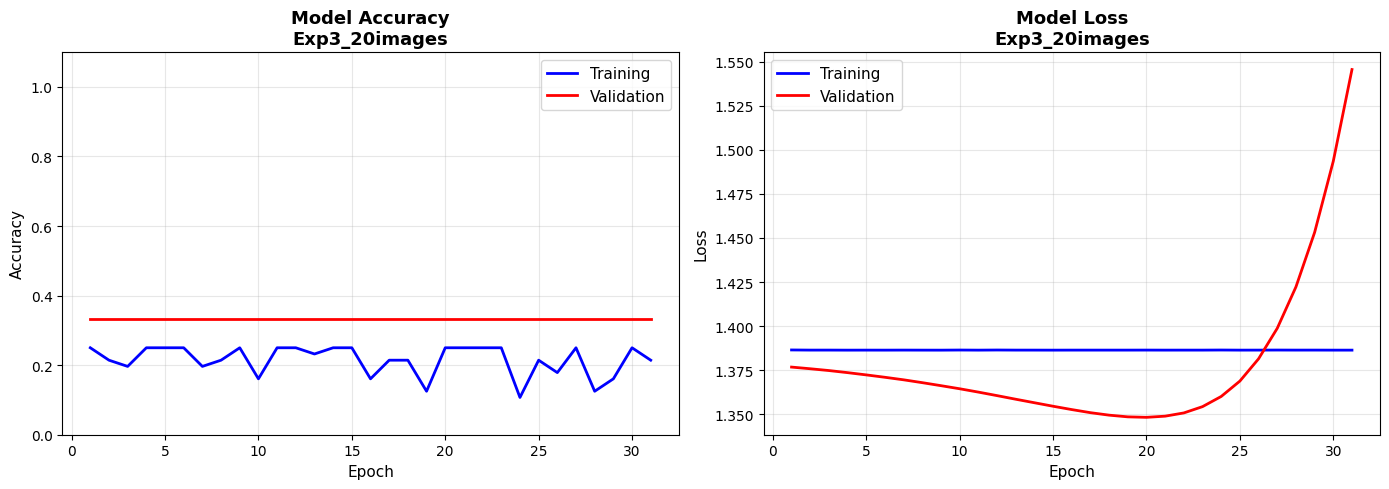

Saved: /content/drive/MyDrive/face_results/training_curves_Exp3_20images.png


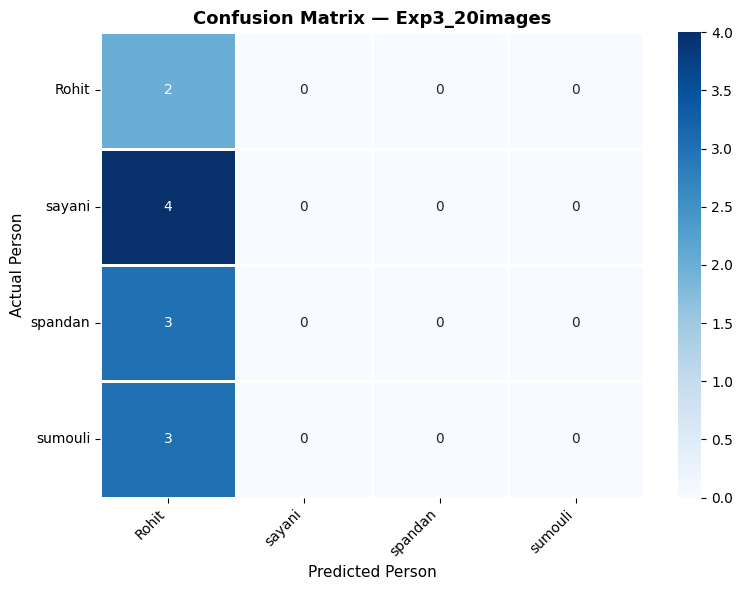

Saved: /content/drive/MyDrive/face_results/confusion_matrix_Exp3_20images.png

Experiment 3 Complete!
Accuracy: 16.67%


In [ ]:
# CELL 12: EXPERIMENT 3 — 20 images per person

print("EXPERIMENT 3 STARTING")
print("Training CNN with 20 images per person")
print("="*50)

results_20, model_20, history_20, people = train_experiment(
    num_images_per_person = 20,
    experiment_name = "Exp3_20images"
)

print("\nExperiment 3 Complete!")
print(f"Accuracy: {results_20['accuracy']}%")


                   FINAL RESULTS SUMMARY                 
  Experiment                  Acc     Prec      Rec       F1
-----------------------------------------------------------------
  Exp1_10images            33.33%   11.11%   33.33%   16.67%
  Exp2_15images            44.44%   19.75%   44.44%   27.35%
  Exp3_20images            16.67%    2.78%   16.67%    4.76%


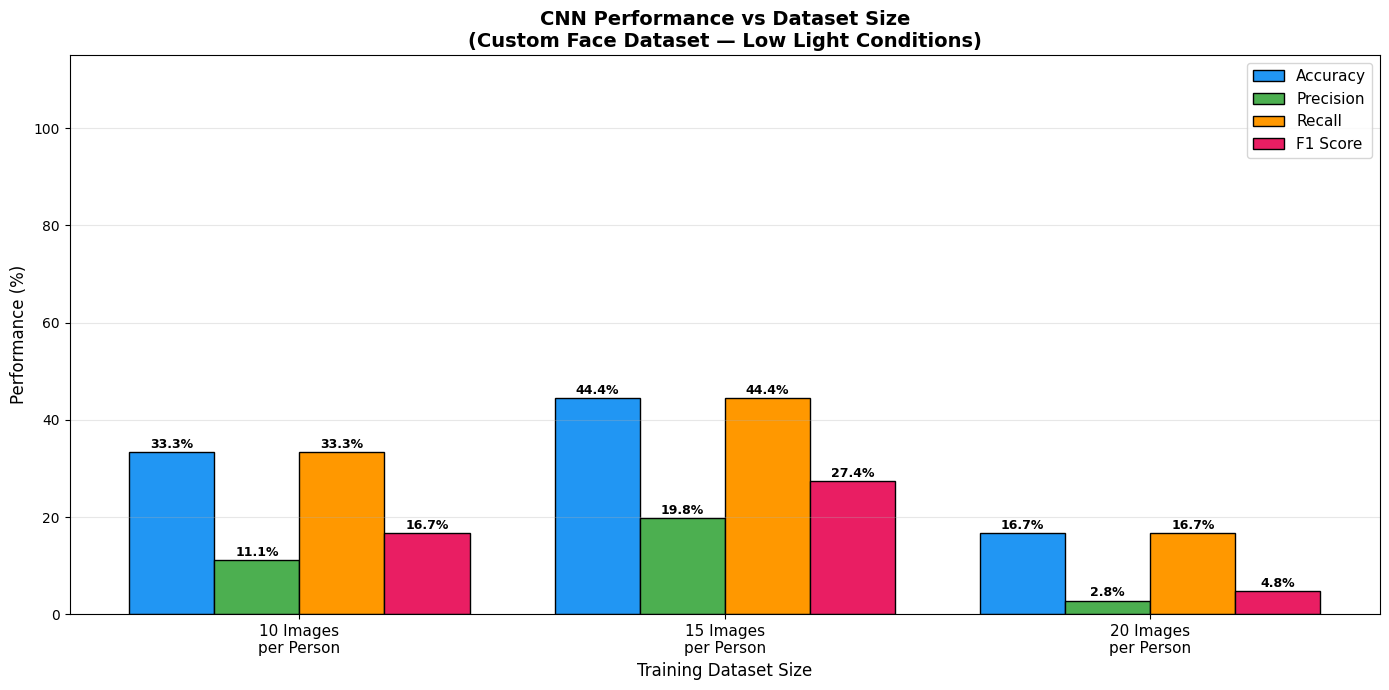


Saved: /content/drive/MyDrive/face_results/final_comparison_CNN.png
This graph goes directly into your paper!


In [ ]:
# CELL 13: Generate final comparison

all_results = [results_10, results_15, results_20]

# Print comparison table
print("\n" + "="*65)
print(f"  {'FINAL RESULTS SUMMARY':^55}")
print("="*65)
print(f"  {'Experiment':<22} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*65)

for r in all_results:
    print(f"  {r['experiment']:<22} "
          f"{r['accuracy']:>7.2f}% "
          f"{r['precision']:>7.2f}% "
          f"{r['recall']:>7.2f}% "
          f"{r['f1_score']:>7.2f}%")

print("="*65)

# Generate comparison chart
plot_final_comparison(all_results)

Testing CNN performance across lighting conditions...
Using best model (20 images per person)

Loading 20 images per person...
  Rohit          : 20 images loaded
  sayani         : 20 images loaded
  spandan        : 20 images loaded
  sumouli        : 20 images loaded

Total loaded: 80 images
Shape: (80, 128, 128, 1)
Classes: 4 people

Data Split:
  Train      : 56 images
  Validation : 12 images
  Test       : 12 images

Testing across lighting conditions...
  Normal Light   : 16.67%
  Dim Light      : 16.67%
  Low Light      : 16.67%
  Very Dark      : 16.67%


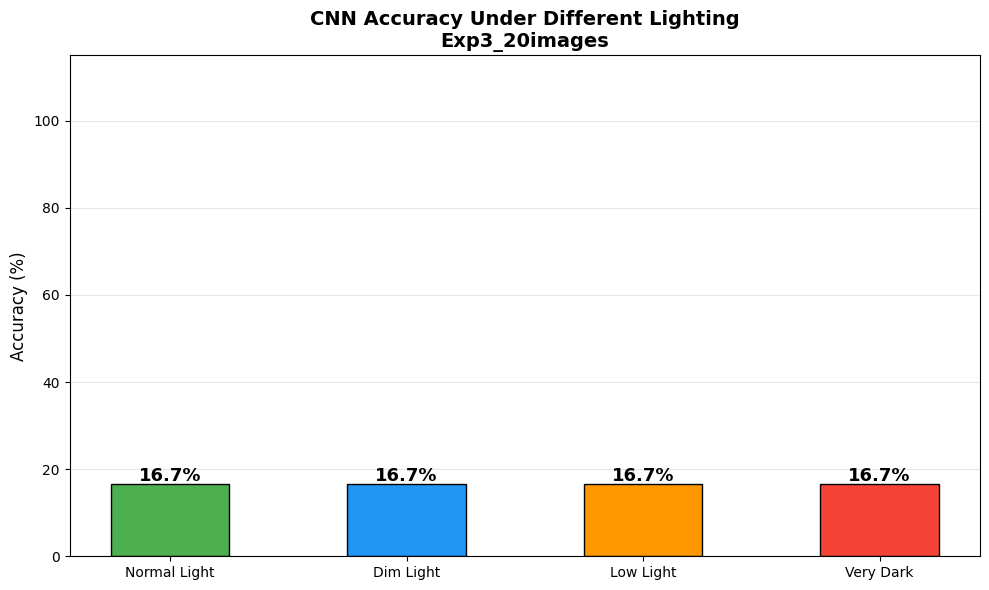

Saved: /content/drive/MyDrive/face_results/lighting_performance_Exp3_20images.png

Key Finding for Your Paper:
CNN accuracy DROPS in low light conditions.
This proves the PROBLEM your paper addresses!
BiLSTM will fix this in the next phase.


In [ ]:
# CELL 14: Test best model across lighting conditions
# Uses the model trained on 20 images (best model)

print("Testing CNN performance across lighting conditions...")
print("Using best model (20 images per person)")
print("="*50)

# Load test data from 20-image experiment
X_all, y_all, people = load_dataset(DATASET_PATH, 20)
num_classes = len(people)
y_cat = to_categorical(y_all, num_classes)

_, _, X_test_normal, _, _, y_test = split_data(
    X_all, y_all, num_classes
)

# Test across lighting levels
lighting_results = plot_lighting_performance(
    model_20,
    X_test_normal,
    y_test,
    "Exp3_20images"
)

print("\nKey Finding for Your Paper:")
print("CNN accuracy DROPS in low light conditions.")
print("This proves the PROBLEM your paper addresses!")
print("BiLSTM will fix this in the next phase.")

In [ ]:
# CELL 15: Save summary and confirm all files saved

print("Saving final summary...")

summary = {
    'experiment_1': results_10,
    'experiment_2': results_15,
    'experiment_3': results_20,
    'conclusion': {
        'best_accuracy': max(
            results_10['accuracy'],
            results_15['accuracy'],
            results_20['accuracy']
        ),
        'best_experiment': max(
            [results_10, results_15, results_20],
            key=lambda x: x['accuracy']
        )['experiment'],
        'observation': 'More training data improves accuracy'
    }
}

summary_file = os.path.join(RESULTS_PATH, 'CNN_complete_summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=4)

print("\n" + "="*55)
print("  ALL FILES SAVED TO GOOGLE DRIVE")
print("="*55)
print(f"\nCheck this folder in your Drive:")
print(f"  {RESULTS_PATH}")
print(f"\nFiles saved:")
print(f"  training_curves_Exp1_10images.png")
print(f"  training_curves_Exp2_15images.png")
print(f"  training_curves_Exp3_20images.png")
print(f"  confusion_matrix_Exp1_10images.png")
print(f"  confusion_matrix_Exp2_15images.png")
print(f"  confusion_matrix_Exp3_20images.png")
print(f"  lighting_performance_Exp3_20images.png")
print(f"  final_comparison_CNN.png")
print(f"  CNN_complete_summary.json")
print(f"\nModels saved:")
print(f"  {MODELS_PATH}/cnn_Exp1_10images.h5")
print(f"  {MODELS_PATH}/cnn_Exp2_15images.h5")
print(f"  {MODELS_PATH}/cnn_Exp3_20images.h5")
print("\n✅ CNN PHASE COMPLETE!")
print("Come back to add BiLSTM on top of this!")


Saving final summary...

  ALL FILES SAVED TO GOOGLE DRIVE

Check this folder in your Drive:
  /content/drive/MyDrive/face_results

Files saved:
  training_curves_Exp1_10images.png
  training_curves_Exp2_15images.png
  training_curves_Exp3_20images.png
  confusion_matrix_Exp1_10images.png
  confusion_matrix_Exp2_15images.png
  confusion_matrix_Exp3_20images.png
  lighting_performance_Exp3_20images.png
  final_comparison_CNN.png
  CNN_complete_summary.json

Models saved:
  /content/drive/MyDrive/face_models/cnn_Exp1_10images.h5
  /content/drive/MyDrive/face_models/cnn_Exp2_15images.h5
  /content/drive/MyDrive/face_models/cnn_Exp3_20images.h5

✅ CNN PHASE COMPLETE!
Come back to add BiLSTM on top of this!
